
CENÁRIO LIMPO
MI: {'AUC': np.float64(0.7677844965704624), 'Brier': np.float64(0.19883084134973156), 'ECE': np.float64(0.08316965395538141)}
MAL: {'AUC': np.float64(0.7474103115009487), 'Brier': np.float64(0.20190181924124537), 'ECE': np.float64(0.053723225896617016)}

CENÁRIO ALEATÓRIO
MI: {'AUC': np.float64(0.7329150700304929), 'Brier': np.float64(0.20634375464559052), 'ECE': np.float64(0.05074642504123582)}
MAL: {'AUC': np.float64(0.7141449044233282), 'Brier': np.float64(0.21087178900301473), 'ECE': np.float64(0.05296371724938102)}

CENÁRIO SISTEMÁTICO
MI: {'AUC': np.float64(0.7056522766370596), 'Brier': np.float64(0.2115810601858127), 'ECE': np.float64(0.02860687291970615)}
MAL: {'AUC': np.float64(0.7059955995599559), 'Brier': np.float64(0.210745232104722), 'ECE': np.float64(0.02604539627239293)}


C:\Users\renna\AppData\Local\Temp\ipykernel_62516\234517331.py:152: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bin = df.groupby("bin").mean(numeric_only=True)
C:\Users\renna\AppData\Local\Temp\ipykernel_62516\234517331.py:152: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bin = df.groupby("bin").mean(numeric_only=True)
C:\Users\renna\AppData\Local\Temp\ipykernel_62516\234517331.py:152: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sile

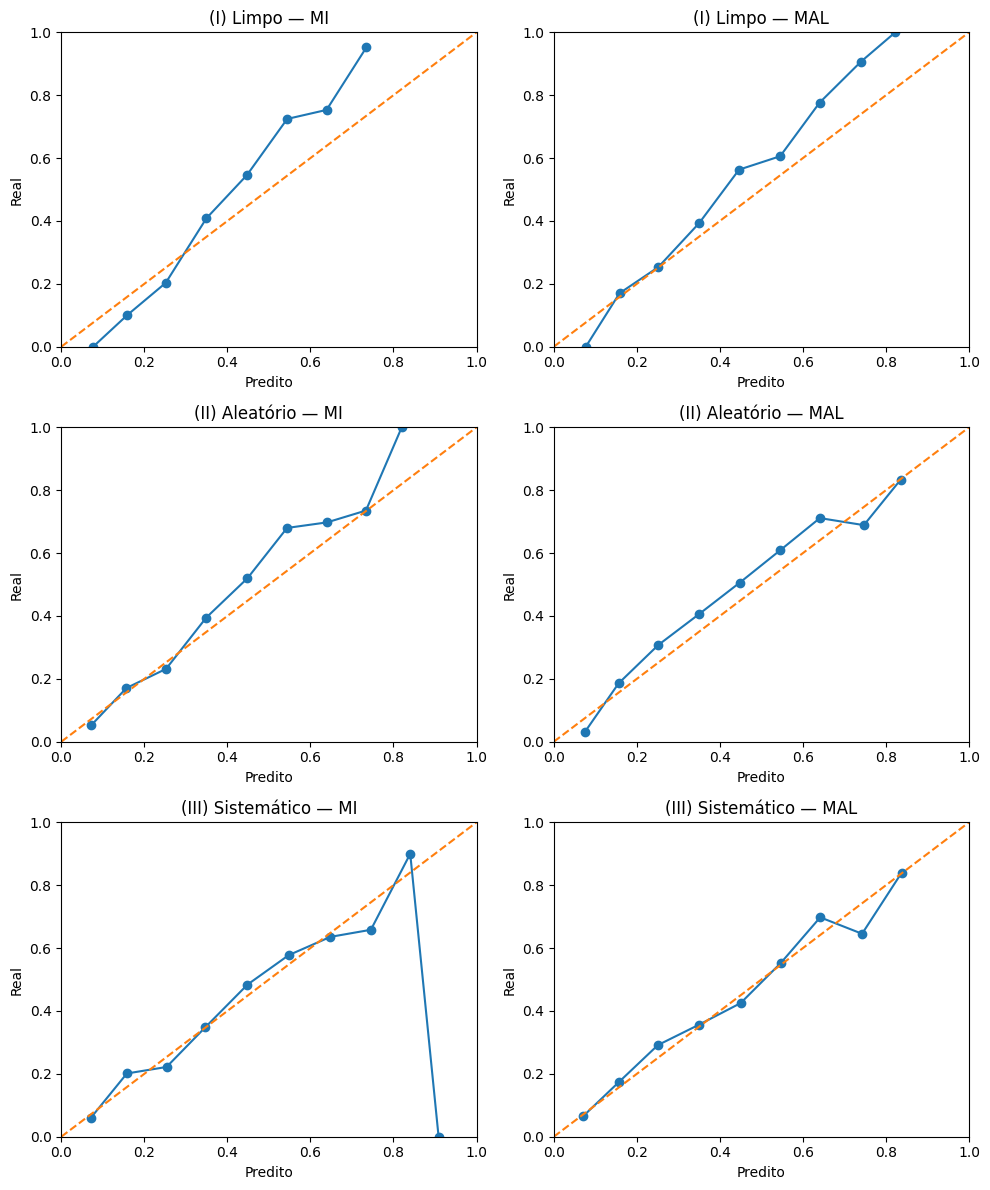

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy.special import expit
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# ---------------- Configurações ---------------- #
np.random.seed(123)

n_train = 1500
n_test  = 1500

alpha = -0.5
beta  = 1.2
sigma = 1.0
delta = 0.7
a     = 1.5

# ---------------- Dados verdadeiros ---------------- #
X_train_true = np.random.normal(0, sigma, n_train)
X_test_true  = np.random.normal(0, sigma, n_test)

p_train = expit(alpha + beta * X_train_true)
p_test  = expit(alpha + beta * X_test_true)

Y_train = np.random.binomial(1, p_train)
Y_test  = np.random.binomial(1, p_test)

# ---------------- Ruído ---------------- #
U_train = np.random.uniform(-a, a, n_train)
U_test  = np.random.uniform(-a, a, n_test)

# ---------------- Processos ---------------- #
processo_train = np.random.choice([0,1,2], n_train)

X_train_obs = X_train_true.copy()

# erro aleatório
mask1 = processo_train == 1
X_train_obs[mask1] = X_train_true[mask1] + U_train[mask1]

# erro sistemático
mask2 = processo_train == 2
X_train_obs[mask2] = X_train_true[mask2] + delta + U_train[mask2]

# ---------------- MODELOS ---------------- #

# MI
model_MI = LogisticRegression()
model_MI.fit(X_train_obs.reshape(-1,1), Y_train)

# MAL (one-hot encoding do processo)
X_MAL = np.column_stack([
    X_train_obs,
    (processo_train == 1).astype(int),
    (processo_train == 2).astype(int)
])

model_MAL = LogisticRegression()
model_MAL.fit(X_MAL, Y_train)

# ---------------- CENÁRIOS ---------------- #

# Limpo
X_test_clean = X_test_true.copy()
proc_clean   = np.random.choice([0,1,2], n_test)

# Aleatório
X_test_rand = X_test_true.copy()
mask = proc_clean == 1
X_test_rand[mask] += U_test[mask]

# Sistemático
X_test_syst = X_test_true.copy()
mask1 = proc_clean == 1
mask2 = proc_clean == 2

X_test_syst[mask1] += U_test[mask1]
X_test_syst[mask2] += delta + U_test[mask2]

# ---------------- Predição ---------------- #

def pred_MI(model, X):
    return model.predict_proba(X.reshape(-1,1))[:,1]

def pred_MAL(model, X, proc):
    X_full = np.column_stack([
        X,
        (proc == 1).astype(int),
        (proc == 2).astype(int)
    ])
    return model.predict_proba(X_full)[:,1]

# previsões
p_MI_clean  = pred_MI(model_MI, X_test_clean)
p_MAL_clean = pred_MAL(model_MAL, X_test_clean, proc_clean)

p_MI_rand  = pred_MI(model_MI, X_test_rand)
p_MAL_rand = pred_MAL(model_MAL, X_test_rand, proc_clean)

p_MI_syst  = pred_MI(model_MI, X_test_syst)
p_MAL_syst = pred_MAL(model_MAL, X_test_syst, proc_clean)

# ---------------- MÉTRICAS ---------------- #

def brier(y, p):
    return np.mean((y - p)**2)

def auc_manual(y, score):
    r = score.argsort().argsort()
    n1 = np.sum(y==1)
    n0 = np.sum(y==0)
    return (np.sum(r[y==1]) - n1*(n1-1)/2) / (n1*n0)

def ece(y, p, bins=10):
    bins_edges = np.linspace(0,1,bins+1)
    ece_val = 0
    for i in range(bins):
        mask = (p >= bins_edges[i]) & (p < bins_edges[i+1])
        if np.sum(mask) == 0:
            continue
        ece_val += np.mean(mask) * abs(np.mean(y[mask]) - np.mean(p[mask]))
    return ece_val

def metrics(y, p):
    return {
        "AUC": auc_manual(y,p),
        "Brier": brier(y,p),
        "ECE": ece(y,p)
    }

# ---------------- RESULTADOS ---------------- #

print("\nCENÁRIO LIMPO")
print("MI:", metrics(Y_test, p_MI_clean))
print("MAL:", metrics(Y_test, p_MAL_clean))

print("\nCENÁRIO ALEATÓRIO")
print("MI:", metrics(Y_test, p_MI_rand))
print("MAL:", metrics(Y_test, p_MAL_rand))

print("\nCENÁRIO SISTEMÁTICO")
print("MI:", metrics(Y_test, p_MI_syst))
print("MAL:", metrics(Y_test, p_MAL_syst))

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

def calib_plot_ax(ax, y, p, title="", bins=10):
    df = pd.DataFrame({"y": y, "p": p})
    df["bin"] = pd.cut(df["p"], bins=np.linspace(0,1,bins+1), include_lowest=True)
    df_bin = df.groupby("bin").mean(numeric_only=True)

    ax.plot(df_bin["p"], df_bin["y"], marker='o')
    ax.plot([0,1], [0,1], linestyle='--')
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_title(title)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

# linha 1
calib_plot_ax(axes[0,0], Y_test, p_MI_clean,  "(I) Limpo — MI")
calib_plot_ax(axes[0,1], Y_test, p_MAL_clean, "(I) Limpo — MAL")

# linha 2
calib_plot_ax(axes[1,0], Y_test, p_MI_rand,  "(II) Aleatório — MI")
calib_plot_ax(axes[1,1], Y_test, p_MAL_rand, "(II) Aleatório — MAL")

# linha 3
calib_plot_ax(axes[2,0], Y_test, p_MI_syst,  "(III) Sistemático — MI")
calib_plot_ax(axes[2,1], Y_test, p_MAL_syst, "(III) Sistemático — MAL")

plt.tight_layout()
plt.show()

### Avaliação Comparativa dos Modelos sob Diferentes Mecanismos de Erro de Medição

A avaliação do desempenho preditivo dos modelos foi conduzida considerando três aspectos fundamentais em problemas de classificação probabilística: **discriminação**, **erro probabilístico** e **calibração**. Para isso, foram utilizadas, respectivamente, a área sob a curva ROC (AUC), o escore de Brier e o *Expected Calibration Error* (ECE). A análise foi realizada em três cenários distintos: (i) cenário limpo, (ii) cenário com erro aleatório e (iii) cenário com erro sistemático persistente.

No **cenário limpo**, em que todas as observações são corretamente mensuradas, o modelo ingênuo (MI) apresentou desempenho superior em termos de discriminação (AUC mais elevada) e erro probabilístico (menor escore de Brier). Esse resultado é esperado, uma vez que não há distorções nos dados que justifiquem a inclusão de variáveis adicionais. Nesse contexto, o modelo ajustado (MAL), ao incorporar a informação sobre o processo de mensuração, introduz parâmetros extras que não contribuem para a explicação do fenômeno, resultando em leve perda de eficiência. A calibração de ambos os modelos permanece adequada, com pequenas diferenças entre eles.

No **cenário com erro aleatório**, observa-se uma degradação no desempenho de ambos os modelos, refletida na redução da AUC e no aumento do erro de Brier. Esse comportamento decorre da natureza não estruturada do erro aleatório, modelado como um ruído aditivo de média nula. Como esse tipo de erro não apresenta padrão sistemático, ele não pode ser aprendido ou corrigido explicitamente pelo modelo, mesmo quando a informação sobre o processo de mensuração está disponível. Consequentemente, tanto o MI quanto o MAL apresentam desempenhos semelhantes, indicando que a inclusão da variável indicadora do processo não traz ganhos relevantes nesse cenário.

Por outro lado, no **cenário com erro sistemático persistente**, caracterizado pela presença de um deslocamento constante nas medições associado a determinados processos, observa-se uma diferença significativa entre os modelos. O modelo ingênuo apresenta pior desempenho, tanto em termos de discriminação quanto de calibração, evidenciando dificuldades em generalizar adequadamente para dados afetados por viés de medição. Em contraste, o modelo ajustado (MAL) demonstra maior robustez, apresentando melhor calibração e menor erro probabilístico. Isso ocorre porque a inclusão explícita da variável indicadora do processo de mensuração permite ao modelo capturar o deslocamento sistemático, reduzindo o viés nas estimativas e melhorando a qualidade das predições.

De forma geral, os resultados indicam que a **intensidade do erro aleatório** (controlada pelo parâmetro que define a amplitude do ruído) afeta negativamente ambos os modelos de maneira semelhante, aumentando a variabilidade das predições e reduzindo a capacidade discriminativa. Já a **presença de erro sistemático** introduz viés estrutural, que compromete significativamente o desempenho do modelo ingênuo, mas pode ser parcialmente corrigido quando a fonte do erro é explicitamente modelada.

Por fim, conclui-se que a inclusão da informação sobre o processo de mensuração tende a ser benéfica em situações onde há **erros sistemáticos identificáveis**, pois permite reduzir o viés preditivo e melhorar a calibração do modelo. Entretanto, em cenários livres de erro ou dominados por **ruído aleatório**, essa inclusão pode introduzir complexidade desnecessária, levando a uma leve perda de eficiência sem ganhos significativos de desempenho. Dessa forma, a decisão de incorporar variáveis relacionadas ao processo de medição deve considerar a natureza e a estrutura dos erros presentes nos dados.
